# Clasificación de Imágenes

## Librerías

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

## Código

* Carga del Dataset incluido en keras

In [19]:
print("Cargando MNIST...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print('MNIST cargado con éxito.')
print(f"Conjunto de entrenamiento: {x_train.shape}, Etiquetas: {y_train.shape}")
print(f"Conjunto de prueba: {x_test.shape}, Etiquetas: {y_test.shape}")

Cargando MNIST...
MNIST cargado con éxito.
Conjunto de entrenamiento: (60000, 28, 28), Etiquetas: (60000,)
Conjunto de prueba: (10000, 28, 28), Etiquetas: (10000,)


* Normalizar los datos (de 0-255 a 0-1) para que la red aprenda mejor


In [10]:
x_train, x_test = x_train / 255.0, x_test / 255.0

* Visualizar un ejemplo (¡Importante para que vean qué estamos analizando!)


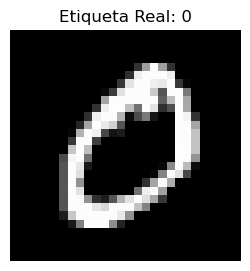

In [11]:
n = 1
plt.figure(figsize=(3,3))
plt.imshow(x_train[n], cmap='gray')
plt.title(f"Etiqueta Real: {y_train[n]}")
plt.axis('off')
plt.show()

* Crear el Modelo (Red Neuronal Secuencial)

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)), # Aplana la imagen 2D a un vector 1D
    tf.keras.layers.Dense(128, activation='relu'), # Capa oculta con 128 neuronas
    tf.keras.layers.Dropout(0.2),                  # Apaga neuronas al azar para evitar memorización
    tf.keras.layers.Dense(10, activation='softmax') # Capa de salida (10 neuronas = 10 dígitos)
])

d:\conda_env\clase_muestra_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


* Compilar el modelo


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

* Entrenar (Fit)

In [20]:
print("\n--- Iniciando Entrenamiento ---")
model.fit(x_train, y_train, epochs=3)


--- Iniciando Entrenamiento ---
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9165 - loss: 6.5449 
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8439 - loss: 1.0255
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8425 - loss: 0.7683


* Evaluar con datos que nunca ha visto

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nPrecisión en el examen final (Test set): {accuracy*100:.2f}%")


Precisión en el examen final (Test set): 97.27%


## DEMO FINAL: Predicción visual

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


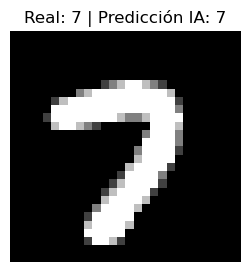

In [25]:

# Tomamos una imagen del set de prueba al azar
indice = np.random.randint(0, len(x_test))
imagen = x_test[indice]
etiqueta_real = y_test[indice]

# Hacemos la predicción
prediccion_raw = model.predict(imagen.reshape(1, 28, 28))
prediccion_digito = np.argmax(prediccion_raw)

# Mostramos resultado
plt.figure(figsize=(3,3))
plt.imshow(imagen, cmap='gray')
plt.title(f"Real: {etiqueta_real} | Predicción IA: {prediccion_digito}")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


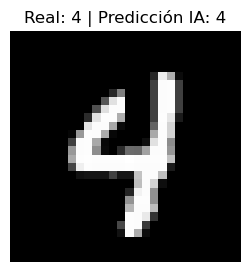